<a href="https://colab.research.google.com/github/rahmani3101/Machine-Learning-/blob/main/PCA(iris).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Principal Component Analysis (PCA) on Iris Dataset

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load the Iris Dataset

The Iris dataset is located at `/content/iris.data`. It does not have a header, so we will manually assign column names. The last column is the species name.

In [ ]:
url = '/content/iris.data'
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
iris_df = pd.read_csv(url, names=column_names)

print("First 5 rows of the Iris dataset:")
display(iris_df.head())

First 5 rows of the Iris dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### 2. Standardize the features

PCA is affected by scale, so it's important to standardize the features before applying PCA.

In [ ]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
x = iris_df[features].values
y = iris_df['species'].values

x_scaled = StandardScaler().fit_transform(x)

print("Shape of scaled features:", x_scaled.shape)

Shape of scaled features: (150, 4)


### 3. Apply PCA to obtain the first two principal components

We will reduce the dimensionality to 2 principal components.

In [ ]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(x_scaled)

pca_df = pd.DataFrame(data=principal_components, columns=['principal_component_1', 'principal_component_2'])


In [ ]:
pca_df.head()

,principal_component_1,principal_component_2
0,-2.264542,0.505704
1,-2.086426,-0.655405
2,-2.367950,-0.318477
3,-2.304197,-0.575368
4,-2.388777,0.674767


In [ ]:
final_df = pd.concat([pca_df, iris_df[['species']]], axis=1)

print("First 5 rows of the DataFrame with Principal Components:")
display(final_df.head())

First 5 rows of the DataFrame with Principal Components:


,principal_component_1,principal_component_2,species
0,-2.264542,0.505704,Iris-setosa
1,-2.086426,-0.655405,Iris-setosa
2,-2.367950,-0.318477,Iris-setosa
3,-2.304197,-0.575368,Iris-setosa
4,-2.388777,0.674767,Iris-setosa


### 4. Plot the data using these two components and color the points based on

*   List item
*   List item

species

Visualizing the data in the reduced dimension.

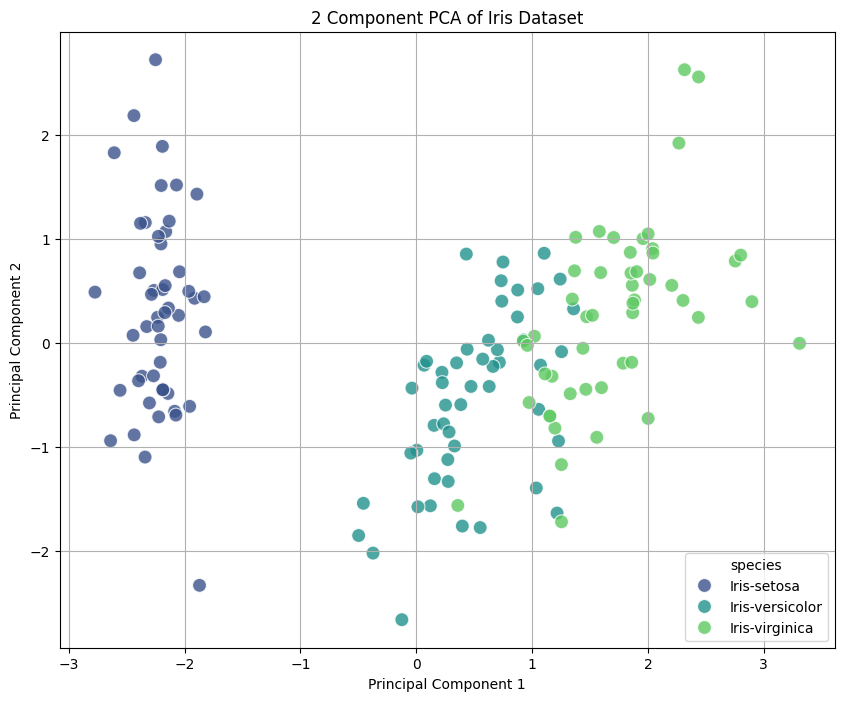

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='principal_component_1',
    y='principal_component_2',
    hue='species',
    data=final_df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('2 Component PCA of Iris Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid()
plt.show()

### 5. Interpret how well the principal components separate the different species

Let's analyze the explained variance ratio to understand how much information each principal component captures.

In [ ]:
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance by principal component 1: {explained_variance[0]:.2f}")
print(f"Explained variance by principal component 2: {explained_variance[1]:.2f}")
print(f"Total explained variance by 2 components: {explained_variance.sum():.2f}")

Explained variance by principal component 1: 0.73
Explained variance by principal component 2: 0.23
Total explained variance by 2 components: 0.96
